<a href="https://colab.research.google.com/github/IvanMalkS/ames-housing-predictions/blob/master/Ames.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [4]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

house_prices_advanced_regression_techniques_path = kagglehub.competition_download('house-prices-advanced-regression-techniques')

print('Data source import complete.')


100%|██████████| 199k/199k [00:00<00:00, 39.5MB/s]

Extracting files...
Data source import complete.


# Boston prices reserch

## Blocks

1) Exploration Data Analysis (EDA)
2) Data processing
3) Models treining
4) Feature engeneering
5) Ansamble models
6) Results

In [5]:
!pip install catboost
!pip install xgboost
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from scipy.stats import randint, uniform

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, mean_squared_error, make_scorer, mean_absolute_percentage_error

from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor, VotingRegressor, StackingRegressor

from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

## EDA


### Data load

In [8]:
Train = pd.read_csv(house_prices_advanced_regression_techniques_path + '/train.csv')
Test = pd.read_csv(house_prices_advanced_regression_techniques_path + '/test.csv')

In [9]:
print(Train.shape)

Train.head(5)

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [10]:
print(Test.shape)

Test.head(5)

(1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


On the date we could see a lot of `NaN` valuse, that we should replace by mean values

In [11]:
Train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [12]:
Train.columns.values

array(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu',
       'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars',
       'GarageArea', 'GarageQual', 'GarageCond', 'Pav

Let's divide x and y, where y is `SalePrice`

In [13]:
X = Train.drop(['SalePrice'], axis=1)
Y = Train['SalePrice']

### Data visualization



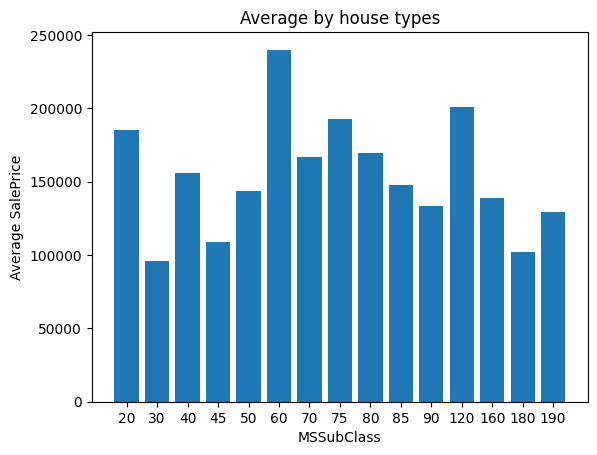

In [14]:
group_data = Train.groupby('MSSubClass')['SalePrice'].mean()

plt.bar(group_data.index.astype(str), group_data.values)
plt.xlabel('MSSubClass')
plt.ylabel('Average SalePrice')
plt.title('Average by house types')
plt.show()

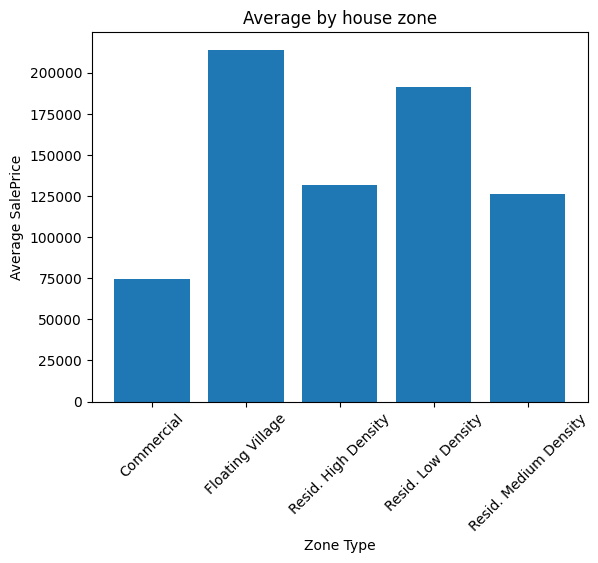

In [15]:
zoning_map = {
    'C (all)': 'Commercial',
    'FV': 'Floating Village',
    'RH': 'Resid. High Density',
    'RL': 'Resid. Low Density',
    'RM': 'Resid. Medium Density'
}

group_data = Train.groupby('MSZoning')['SalePrice'].mean()

plot_index = group_data.index.map(zoning_map)

plt.bar(plot_index, group_data.values)
plt.xlabel('Zone Type')
plt.ylabel('Average SalePrice')
plt.title('Average by house zone')
plt.xticks(rotation=45)
plt.show()

we can see that the most priced zone is floating vilages and low density zones

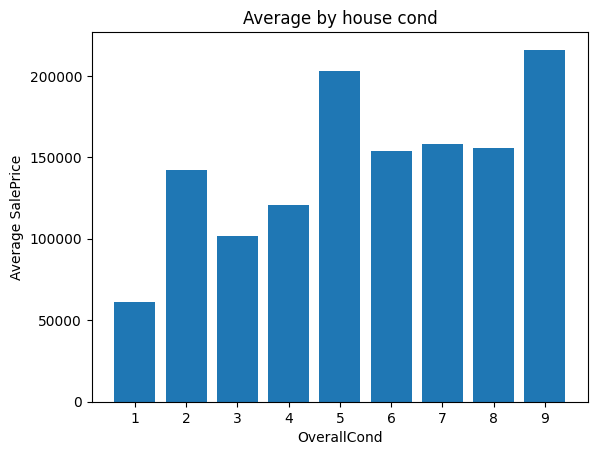

In [16]:
group_data = Train.groupby('OverallCond')['SalePrice'].mean()

plt.bar(group_data.index.astype(str), group_data.values)
plt.xlabel('OverallCond')
plt.ylabel('Average SalePrice')
plt.title('Average by house cond')
plt.show()

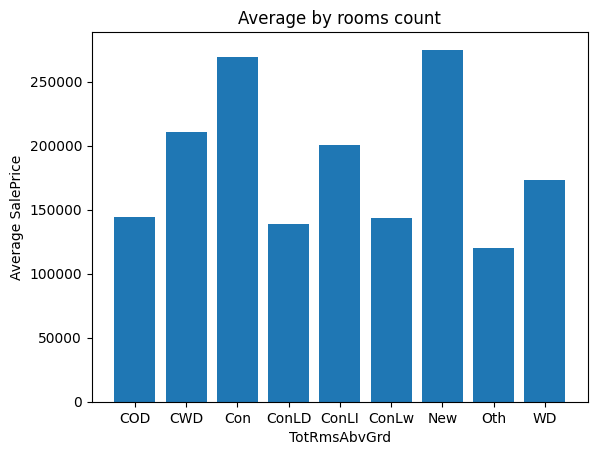

In [17]:
group_data = Train.groupby('SaleType')['SalePrice'].mean()

plt.bar(group_data.index.astype(str), group_data.values)
plt.xlabel('TotRmsAbvGrd')
plt.ylabel('Average SalePrice')
plt.title('Average by rooms count')
plt.show()

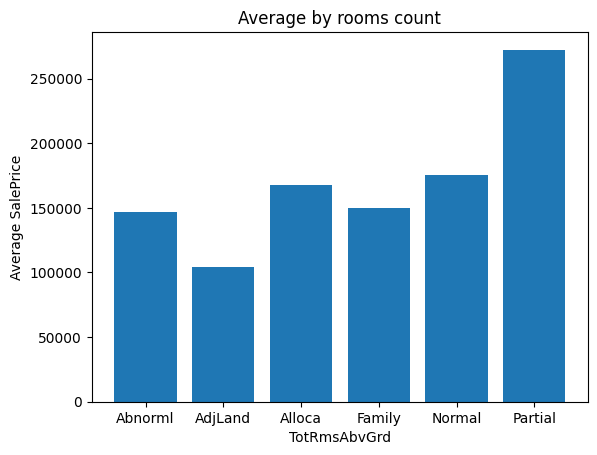

In [18]:
group_data = Train.groupby('SaleCondition')['SalePrice'].mean()

plt.bar(group_data.index.astype(str), group_data.values)
plt.xlabel('TotRmsAbvGrd')
plt.ylabel('Average SalePrice')
plt.title('Average by rooms count')
plt.show()

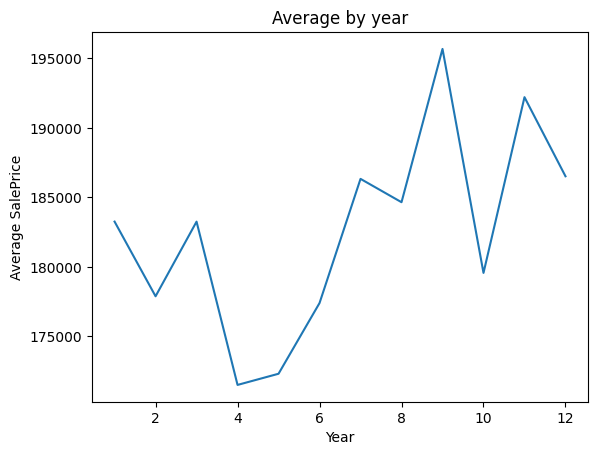

In [19]:
group_data = Train.groupby('MoSold')['SalePrice'].mean()

plt.plot(group_data.index, group_data.values)
plt.xlabel('Year')
plt.ylabel('Average SalePrice')
plt.title('Average by year')
plt.show()

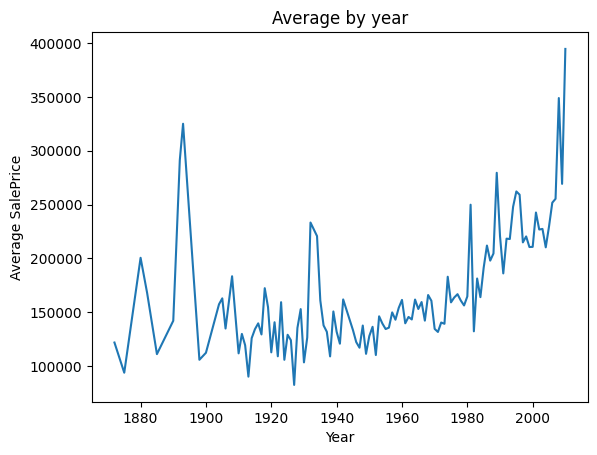

In [20]:
group_data = Train.groupby('YearBuilt')['SalePrice'].mean()

plt.plot(group_data.index, group_data.values)
plt.xlabel('Year')
plt.ylabel('Average SalePrice')
plt.title('Average by year')
plt.show()

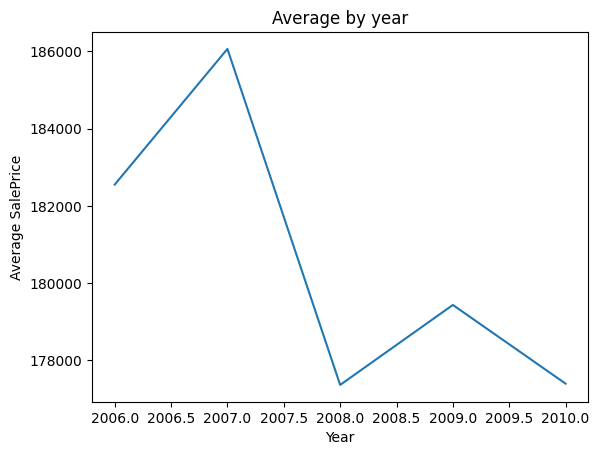

In [21]:
group_data = Train.groupby('YrSold')['SalePrice'].mean()

plt.plot(group_data.index, group_data.values)
plt.xlabel('Year')
plt.ylabel('Average SalePrice')
plt.title('Average by year')
plt.show()

We can see price falls in 2008 - 2010 and great growth in 2007

1) 2007 - The peak of the Mortgage crisis bubble
2) 2008 - The mortgage crisis
3) 2010 - The recession after the crash

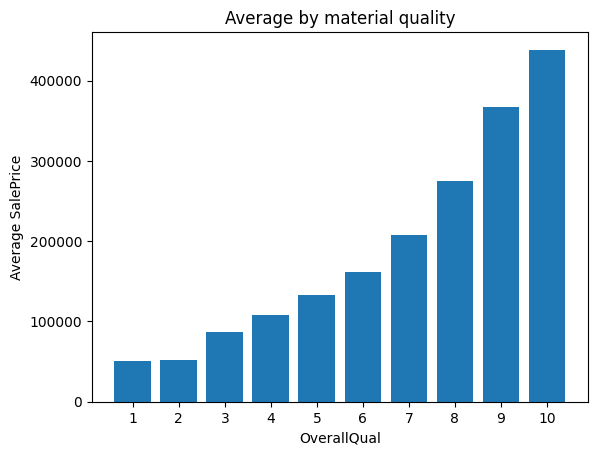

In [22]:
group_data = Train.groupby('OverallQual')['SalePrice'].mean()

plt.bar(group_data.index.astype(str), group_data.values)
plt.xlabel('OverallQual')
plt.ylabel('Average SalePrice')
plt.title('Average by material quality')
plt.show()

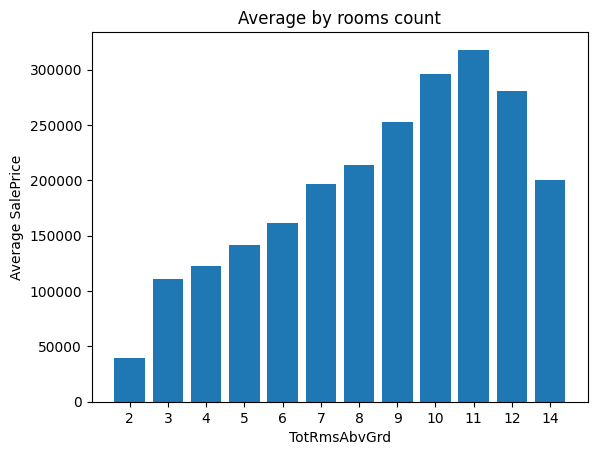

In [23]:
group_data = Train.groupby('TotRmsAbvGrd')['SalePrice'].mean()

plt.bar(group_data.index.astype(str), group_data.values)
plt.xlabel('TotRmsAbvGrd')
plt.ylabel('Average SalePrice')
plt.title('Average by rooms count')
plt.show()

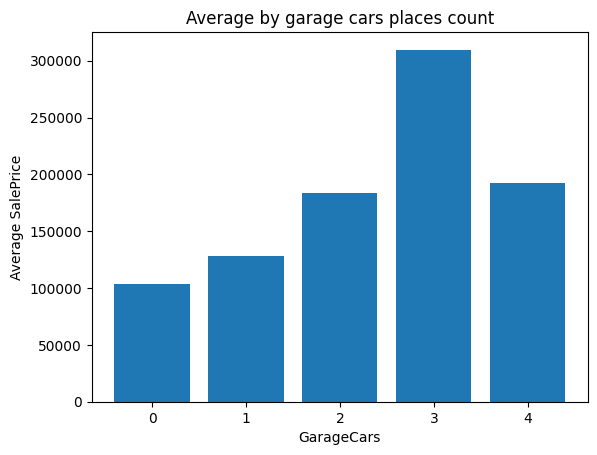

In [24]:
group_data = Train.groupby('GarageCars')['SalePrice'].mean()

plt.bar(group_data.index.astype(str), group_data.values)
plt.xlabel('GarageCars')
plt.ylabel('Average SalePrice')
plt.title('Average by garage cars places count')
plt.show()

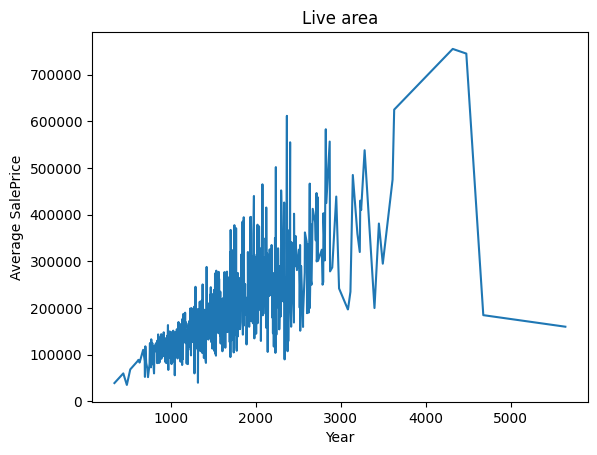

In [25]:
group_data = Train.groupby('GrLivArea')['SalePrice'].mean()

plt.plot(group_data.index, group_data.values)
plt.xlabel('Year')
plt.ylabel('Average SalePrice')
plt.title('Live area')
plt.show()

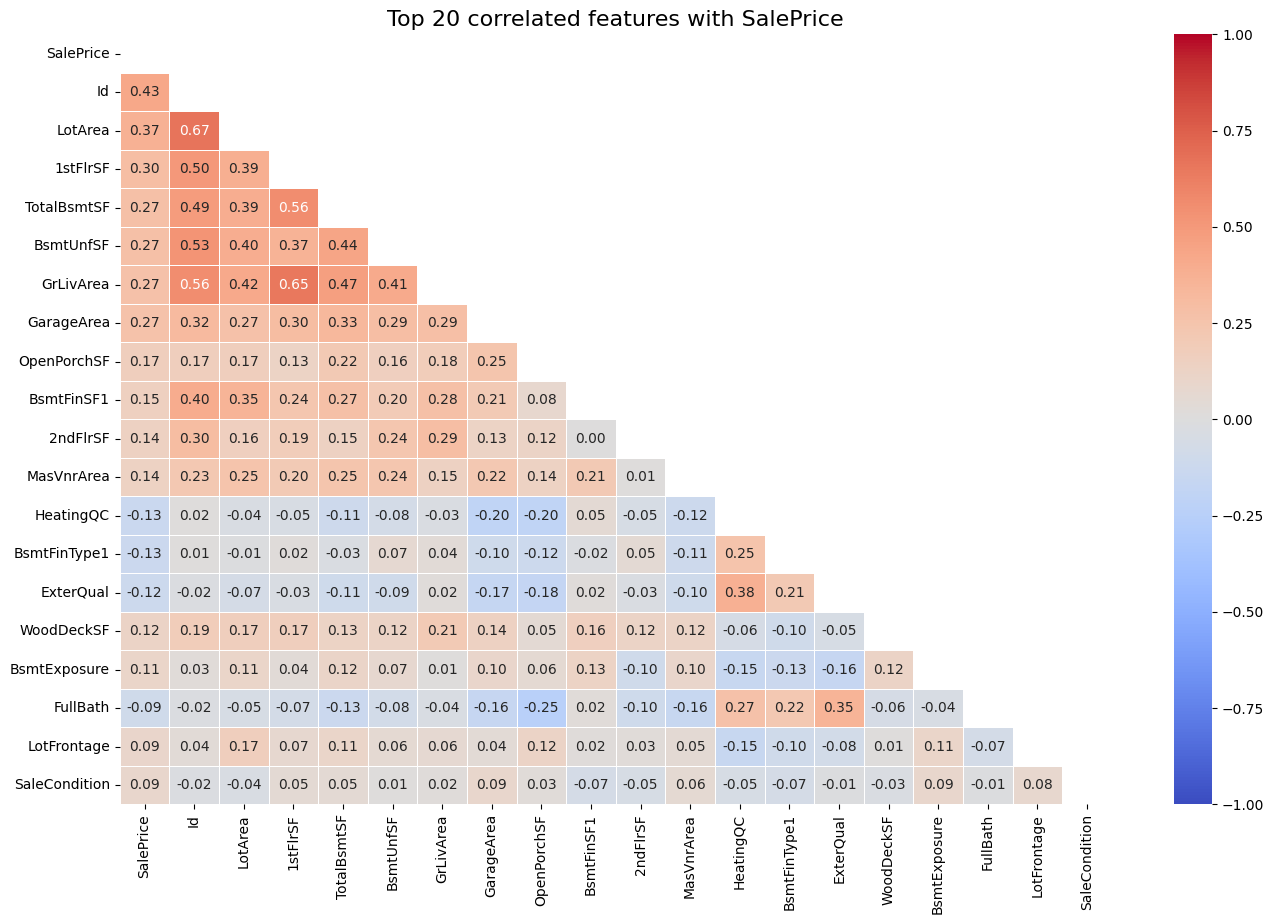

In [26]:
full_df = pd.concat([X, Y], axis=1)

df_encoded = full_df.apply(lambda x: pd.factorize(x)[0])

corr = df_encoded.corr()

top_20_features = corr['SalePrice'].abs().sort_values(ascending=False).head(20).index
top_corr = corr.loc[top_20_features, top_20_features]

plt.figure(figsize=(16, 10))

mask = np.triu(np.ones_like(top_corr, dtype=bool))

ax = sns.heatmap(
    top_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    linewidths=.5,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title("Top 20 correlated features with SalePrice", fontsize=16)
plt.show()

By the **Average by material quality**  and **Average by rooms count** and **Average by garage cars places count** and **Live area** plot seems obvios correlations italicized text

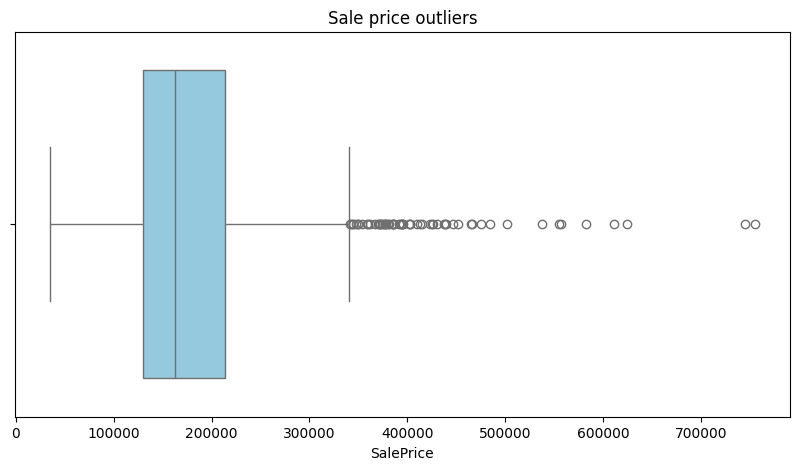

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.boxplot(x=Train['SalePrice'], color='skyblue')
plt.title('Sale price outliers')
plt.show()

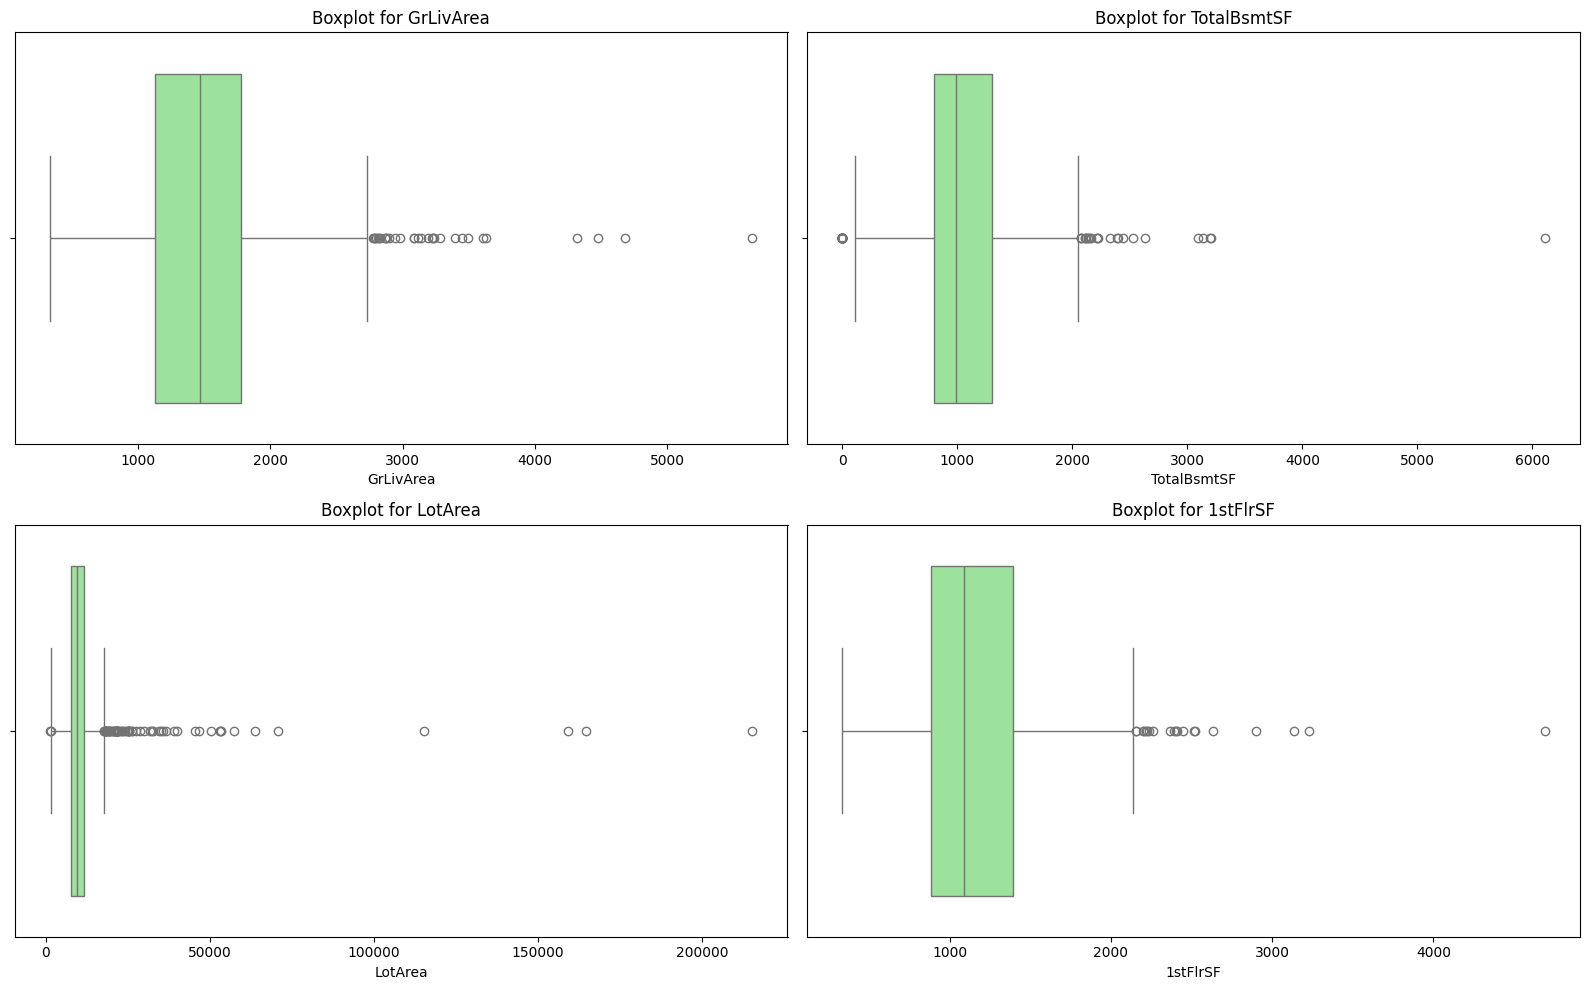

In [28]:
features_to_check = ['GrLivArea', 'TotalBsmtSF', 'LotArea', '1stFlrSF']

plt.figure(figsize=(16, 10))

for i, col in enumerate(features_to_check):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=Train[col], color='lightgreen')
    plt.title(f'Boxplot for {col}')

plt.tight_layout()
plt.show()

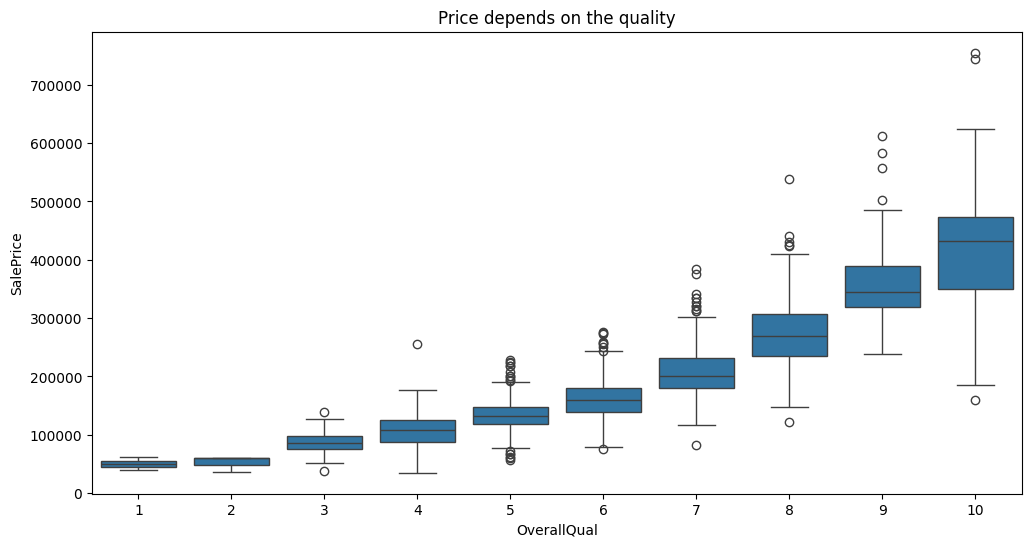

In [29]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=Train)
plt.title('Price depends on the quality')
plt.show()

Text(0.5, 1.0, 'Sale price distibution')

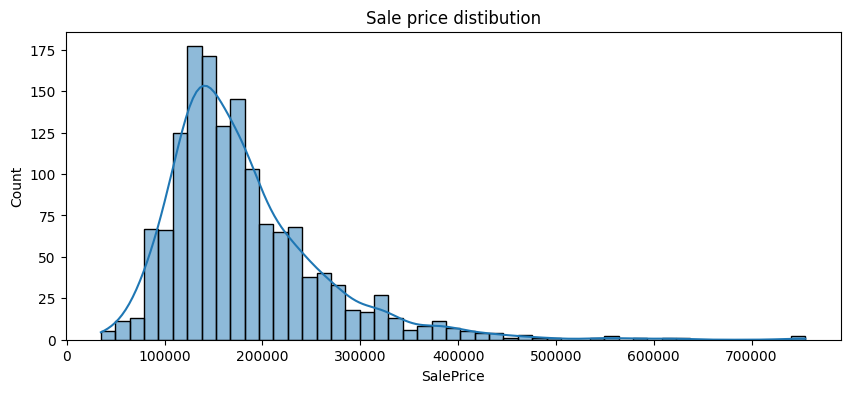

In [30]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
sns.histplot(Train['SalePrice'], kde=True)
plt.title('Sale price distibution')


Looks like log-normal distibution, to my mind is's better convert to normal

### EDA results

1) Data contains a lot of data gaps
2) **Average by material quality** and **Average by rooms count** and **Average by garage cars places count** and **Live area** have correlation with price
3) Crysis directly affects price, see https://en.wikipedia.org/wiki/2008_financial_crisis
4) Outlines not big, however i will reduce them


## Data processing


In [31]:
Train = Train.drop('Id', axis=1)
Train = Train.drop(Train[Train['GrLivArea'] > 4000].index)
Train = Train.drop(Train[Train['TotalBsmtSF'] > 6000].index)


In [32]:
Train["SalePrice"] = np.log1p(Train["SalePrice"])


In [33]:
Train.isnull().sum()[Train.isnull().sum() > 0]
X = Train.drop("SalePrice", axis=1)
y = Train["SalePrice"]


let's fills categorials with None to string categorial values

In [34]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

cat_cols_none = [
    'PoolQC', 'Alley', 'FireplaceQu', 'GarageType', 'GarageFinish',
    'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2', 'MasVnrType', 'Fence', 'MiscFeature'
]

cat_cols_mode = [col for col in X.select_dtypes(include=['object']).columns
                 if col not in cat_cols_none]



In [35]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
  ])
num_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [36]:
cat_none_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
cat_none_pipeline

Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='None', strategy='constant')),
                ('ohe',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [37]:
cat_mode_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
cat_mode_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('ohe',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat_none', cat_none_pipeline, cat_cols_none),
        ('cat_mode', cat_mode_pipeline, cat_cols_mode)
    ]
)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['MSSubClass', 'LotFrontage', 'LotArea',
                                  'OverallQual', 'OverallCond', 'YearBuilt',
                                  'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
                                  'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                                  '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
                                  'GrLivArea', 'BsmtFullBath...
                                 ['MSZoning', 'Street', 'LotShape',
                                  'LandContour', 'Utilities', 'LotConfig',
                                  'LandSlope', 'Neighborhood', 'Condition1',
                                  'Condition2', 'BldgType', 'HouseStyle',
                                  'RoofStyle', 'RoofMatl', 'Exterior1st',
                                  'Exterior2nd', 'ExterQual', 'ExterCond',
                                  'Foundation', 'Heating', 'HeatingQC',
                                  'CentralAir', 'Electrical', 'KitchenQual',
                                  'Functional', 'PavedDrive', 'SaleType',
                                  'SaleCondition'])])

In [39]:
cat_pipeline_simple = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])
cat_pipeline_simple

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('ordinal',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1))])

In [40]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline_simple, cat_cols_none + cat_cols_mode)
    ]
)
preprocessor_tree

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['MSSubClass', 'LotFrontage', 'LotArea',
                                  'OverallQual', 'OverallCond', 'YearBuilt',
                                  'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
                                  'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                                  '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
                                  'GrLivArea', 'BsmtFullBath...
                                 ['PoolQC', 'Alley', 'FireplaceQu',
                                  'GarageType', 'GarageFinish', 'GarageQual',
                                  'GarageCond', 'BsmtQual', 'BsmtCond',
                                  'BsmtExposure', 'BsmtFinType1',
                                  'BsmtFinType2', 'MasVnrType', 'Fence',
                                  'MiscFeature', 'MSZoning', 'Street',
                                  'LotShape', 'LandContour', 'Utilities',
                                  'LotConfig', 'LandSlope', 'Neighborhood',
                                  'Condition1', 'Condition2', 'BldgType',
                                  'HouseStyle', 'RoofStyle', 'RoofMatl',
                                  'Exterior1st', ...])])

In [41]:
X = Train.drop("SalePrice", axis=1)
y = Train["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_binned = pd.qcut(y, q=10, labels=False)


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Models training

### Linear models

In [42]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('lasso', Lasso())
])

param_grid = {
    'lasso__alpha': [0.05, 0.1, 0.5, 1, 5, 10, 15, 20, 30, 50],
}

grid_search_lasso = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=skf.split(X, y_binned),
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search_lasso.fit(X, y)


print(f"Best params: {grid_search_lasso.best_params_}")

best_rmse_lasso = np.sqrt(-grid_search_lasso.best_score_)
print(f"Best RMSE lasso: {best_rmse_lasso:.5f}")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'ridge__alpha': 0.05}
Best RMSE: 0.16321


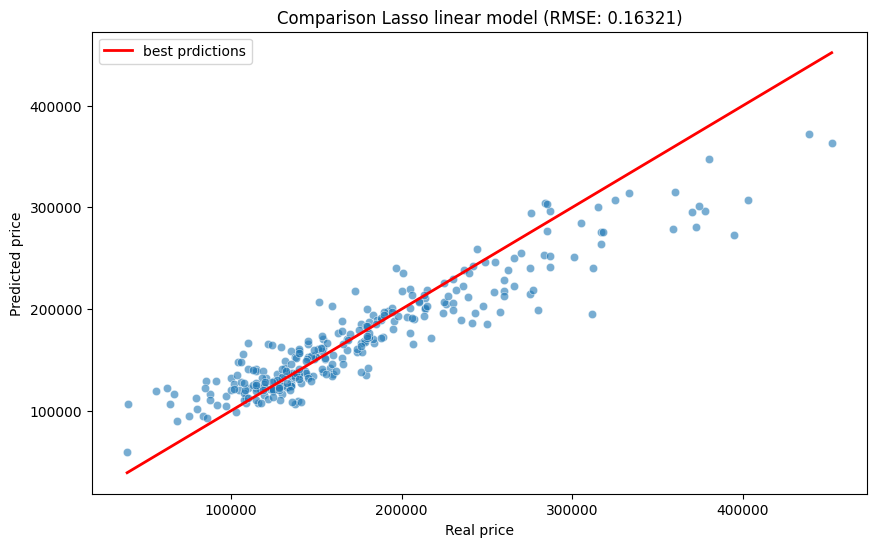

Avg loss: 12.81%


In [43]:
y_test_pred = grid_search_lasso.predict(X_test)

y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)

line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='best prdictions')

plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison Lasso linear model (RMSE: {best_rmse_lasso:.5f})')
plt.legend()
plt.show()

y_true_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_test_pred)


mape = mean_absolute_percentage_error(y_true_dollars, y_pred_dollars)
print(f"Avg loss: {mape*100:.2f}%")



### Ridge modek

In [45]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('ridge', Ridge())
])

param_grid = {
    'ridge__alpha': [0.05, 0.1, 0.5, 1, 5, 10, 15, 20, 30, 50],
}

grid_search_ridge = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=skf.split(X, y_binned),
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search_ridge.fit(X_train, y_train)


print(f"Best params: {grid_search_ridge.best_params_}")
best_ridge_rmse = np.sqrt(-grid_search_ridge.best_score_)
print(f"Ridge Best RMSE (CV): {best_ridge_rmse:.5f}")


y_test_pred_ridge = grid_search_ridge.predict(X_test)
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))
print(f"Ridge Test RMSE: {rmse_test_ridge:.5f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


IndexError: indices are out-of-bounds

In [ ]:
y_test_pred = grid_search_ridge.predict(X_test)

y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)

line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='best prdictions')

plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison Ridge linear model (RMSE: {best_rmse:.5f})')
plt.legend()
plt.show()

y_true_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_test_pred)


mape = mean_absolute_percentage_error(y_true_dollars, y_pred_dollars)
print(f"Avg loss: {mape*100:.2f}%")



In [ ]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('ridge', ElasticNet())
])

param_grid = {
    'ridge__alpha': [0.01, 0.05],
    'ridge__l1_ratio': [0.1, 0.3],
    'ridge__max_iter': [1000, 3000],
    'ridge__tol': [0.0001, 0.001]
}

grid_search_elastic_net = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=skf.split(X, y_binned),
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search_elastic_net.fit(X, y)


print(f"Best params: {grid_search_elastic_net.best_params_}")

best_rmse = np.sqrt(-grid_search_elastic_net.best_score_)
print(f"Best RMSE: {best_rmse:.5f}")

In [ ]:
y_test_pred = grid_search_elastic_net.predict(X_test)

y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)

line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='best prdictions')

plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison ElasticNet linear model (RMSE: {best_rmse:.5f})')
plt.legend()
plt.show()

y_true_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_test_pred)


mape = mean_absolute_percentage_error(y_true_dollars, y_pred_dollars)
print(f"Avg loss: {mape*100:.2f}%")



### KNN


In [ ]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsRegressor())
])

param_grid = {
    'knn__n_neighbors': [3, 5, 7, 10, 15, 20, 25],
}

grid_search_knn = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=skf.split(X, y_binned),
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search_knn.fit(X, y)

print(f"Best params: {grid_search_knn.best_params_}")

best_rmse = np.sqrt(-grid_search_knn.best_score_)
print(f"Best RMSE: {best_rmse:.5f}")

In [ ]:
y_test_pred = grid_search_knn.predict(X_test)

y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)

line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='best prdictions')

plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison KNN model (RMSE: {best_rmse:.5f})')
plt.legend()
plt.show()

y_true_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_test_pred)


mape = mean_absolute_percentage_error(y_true_dollars, y_pred_dollars)
print(f"Avg loss: {mape*100:.2f}%")



In [ ]:
svr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('svr', SVR())
])

param_grid_svr = [
    {
        'svr__kernel': ['rbf'],
        'svr__C': [1, 10, 20],
        'svr__gamma': ['scale', 0.001, 0.01],
        'svr__epsilon': [0.01, 0.1]
    },
]

grid_search_svr = GridSearchCV(
    svr_pipeline,
    param_grid_svr,
    cv=skf.split(X, y_binned),
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search_svr.fit(X_train, y_train)

print(f"Лучшее ядро и параметры: {grid_search_svr.best_params_}")
best_svr_rmse = np.sqrt(-grid_search_svr.best_score_)
print(f"SVR RMSE: {best_svr_rmse:.5f}")

In [ ]:
y_test_pred = grid_search_svr.predict(X_test)

y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)

line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='Best predictions')

plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison SVR Model (RMSE: {best_svr_rmse:.5f})')
plt.legend()
plt.show()

y_true_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_test_pred)

from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_true_dollars, y_pred_dollars)
print(f"Avg loss (SVR): {mape*100:.2f}%")

### Desision tree

In [ ]:
desicion_tree_pipeline = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('dt', DecisionTreeRegressor())
])

param_dist_dt = {
    'dt__max_depth': randint(2, 10),
    'dt__min_samples_split': randint(2, 10),
    'dt__min_samples_leaf': randint(1, 5),
    'dt__max_features': ['sqrt', 0.3, 0.5],
    'dt__random_state': [42]
}

random_search_dt = RandomizedSearchCV(
    desicion_tree_pipeline,
    param_distributions=param_dist_dt,
    n_iter=30,
    cv=skf.split(X, y_binned),
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search_dt.fit(X_train, y_train)

best_dt_model = random_search_dt.best_estimator_
y_pred_dt = best_dt_model.predict(X_test)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print(f"DecisionTree Best Params: {random_search_dt.best_params_}")
print(f"DecisionTree RMSE: {rmse_dt:.5f}")

In [ ]:
y_test_pred = random_search_dt.predict(X_test)

y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)

line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='Best predictions')

plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison Random Forest Model (RMSE: {best_svr_rmse:.5f})')
plt.legend()
plt.show()

y_true_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_test_pred)

from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_true_dollars, y_pred_dollars)
print(f"Avg loss (Random Forest): {mape*100:.2f}%")

### Random forest

In [ ]:
random_trees_pipeline = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('rt', RandomForestRegressor(n_jobs=1))
])

param_dist_rt = {
    'rt__n_estimators': randint(500, 1000),
    'rt__max_depth': [None, 10, 20, 30],
    'rt__min_samples_split': randint(2, 10),
    'rt__min_samples_leaf': randint(1, 5),
    'rt__max_features': ['sqrt'],
    'rt__bootstrap': [True, False]
}

random_search_rt = RandomizedSearchCV(
    random_trees_pipeline,
    param_distributions=param_dist_rt,
    n_iter=30,
    cv=skf.split(X, y_binned),
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search_rt.fit(X_train, y_train)

best_et_model = random_search_rt.best_estimator_
y_pred_et = best_et_model.predict(X_test)
rmse_et = np.sqrt(mean_squared_error(y_test, y_pred_et))

print(f"Random forest Best Params: {random_search_rt.best_params_}")
print(f"Random forest RMSE: {rmse_et:.5f}")

In [ ]:
y_test_pred = random_search_rt.predict(X_test)

y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)

line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='Best predictions')

plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison Random Forest Model (RMSE: {best_svr_rmse:.5f})')
plt.legend()
plt.show()

y_true_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_test_pred)

from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_true_dollars, y_pred_dollars)
print(f"Avg loss (Random Forest): {mape*100:.2f}%")

### Catboost

In [ ]:
param_dist = {
    'catboost__iterations': [500, 1000],
    'catboost__learning_rate': [0.01, 0.05, 0.15],
    'catboost__depth': [2, 4],
    'catboost__l2_leaf_reg': [1, 3]
}

cat_pipeline = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('catboost', CatBoostRegressor(
        random_state=42,
        verbose=0,
        thread_count=-1
    ))
])

random_search_cat = RandomizedSearchCV(
    cat_pipeline,
    param_distributions=param_dist,
    n_iter=15,
    cv=skf.split(X, y_binned),
    scoring='neg_mean_squared_error',
    verbose=2,
    n_jobs=2,
    random_state=42
)


random_search_cat.fit(X_train, y_train)

y_pred_cat = random_search_cat.predict(X_test)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
best_model = random_search_cat.best_estimator_
print(f"Best params: {random_search_cat.best_params_}")
print(f"CatBoost RMSE: {rmse_cat:.5f}")

In [ ]:
y_test_pred = random_search_cat.predict(X_test)

y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)

line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='Best predictions')

plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison SVR Model (RMSE: {best_svr_rmse:.5f})')
plt.legend()
plt.show()

y_true_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_test_pred)

from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_true_dollars, y_pred_dollars)
print(f"Avg loss (SVR): {mape*100:.2f}%")

### LightGBM


In [ ]:
lightgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('lightgbm', LGBMRegressor(
        random_state=42,
        device=device,
        verbosity=-1
    ))
])

param_dist_lightgbm = {
    'lightgbm__n_estimators': [300, 500],
    'lightgbm__learning_rate': [0.05, 0.1],
    'lightgbm__num_leaves': [15, 31],
    'lightgbm__max_depth': [4, 6],
    'lightgbm__min_child_samples': [10, 20],
    'lightgbm__subsample': [0.8],
    'lightgbm__colsample_bytree': [0.6, 0.8],
}

random_search_lightgbm = RandomizedSearchCV(
    lightgbm_pipeline,
    param_distributions=param_dist_lightgbm,
    n_iter=15,
    cv=skf.split(X, y_binned),
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search_lightgbm.fit(X_train, y_train)


y_pred_cat = random_search_lightgbm.predict(X_test)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
print(f"lightgbm RMSE: {rmse_cat:.5f}")

In [ ]:
y_test_pred = random_search_cat.predict(X_test)

y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)

line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='Best predictions')

plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison lightgbm Model (RMSE: {best_svr_rmse:.5f})')
plt.legend()
plt.show()

y_true_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_test_pred)

from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_true_dollars, y_pred_dollars)
print(f"Avg loss (lightgbm): {mape*100:.2f}%")
print(f"Avg loss (lightgbm): {mape*100:.2f}%")

### XGBoost

In [ ]:

xgboost_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', XGBRegressor(
        random_state=42,
        device=device,
        verbosity=0
    ))
])

param_dist_xgboost = {
    'xgb__n_estimators': randint(100, 1000),
    'xgb__learning_rate': uniform(0.01, 0.2),
    'xgb__max_depth': randint(3, 10),
    'xgb__min_child_weight': randint(1, 10),
    'xgb__subsample': uniform(0.6, 0.4),
    'xgb__colsample_bytree': uniform(0.5, 0.5),
    'xgb__gamma': uniform(0, 0.5),
    'xgb__reg_alpha': uniform(0, 10),
    'xgb__reg_lambda': uniform(0, 10),
}

random_search_xgboost = RandomizedSearchCV(
    xgboost_pipeline,
    param_distributions=param_dist_xgboost,
    n_iter=50,
    cv=kf,
    scoring='neg_mean_squared_error',
    verbose=0,
    n_jobs=1,
    random_state=42
)

random_search_xgboost.fit(X_train, y_train)

y_pred_xgb = random_search_xgboost.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print(f"Best params: {random_search_xgboost.best_params_}")
print(f"XGBoost RMSE: {rmse_xgb:.5f}")

In [ ]:
y_test_pred = random_search_xgboost.predict(X_test)

y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)

line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='Best predictions')

plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison XGBoost Model (RMSE: {best_svr_rmse:.5f})')
plt.legend()
plt.show()

y_true_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_test_pred)

from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_true_dollars, y_pred_dollars)
print(f"Avg loss (XGBoost): {mape*100:.2f}%")

### DNN


In [ ]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

X_train_tensor = torch.tensor(X_train_transformed, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_transformed, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [ ]:
from torch.utils.data import Dataset, DataLoader

class AmesHousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

ames_dataset = AmesHousingDataset(X_train_tensor, y_train_tensor)
ames_dataloader = DataLoader(ames_dataset, batch_size=32, shuffle=True)

for batch_X, batch_y in ames_dataloader:
    print(batch_X.shape)
    break

In [ ]:
class AmesRegressor(nn.Module):
    def __init__(self, input_dim):
        super(AmesRegressor, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        return self.network(x)


In [ ]:
in_features = X_train_transformed.shape[1]
nn_model = AmesRegressor(in_features).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(nn_model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

val_dataset = AmesHousingDataset(X_test_tensor, y_test_tensor)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)

train_losses = []
val_losses = []

epochs = 100

In [ ]:

for epoch in range(epochs):
    nn_model.train()
    train_loss = 0.0
    for inputs, labels in ames_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = nn_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)

    nn_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = nn_model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)

    scheduler.step()

    epoch_train_loss = train_loss / len(ames_dataloader.dataset)
    epoch_val_loss = val_loss / len(val_dataloader.dataset)


    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f}")

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(train_losses, label='Training Loss (MSE)')
plt.plot(val_losses, label='Validation Loss (MSE)')

plt.title('Ames Housing nn learning')
plt.xlabel('Epoches', fontsize=12)
plt.ylabel('Loss', fontsize=12)

plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.annotate(f'Final Val MSE: {val_losses[-1]:.4f}',
             xy=(len(val_losses)-1, val_losses[-1]),
             xytext=(len(val_losses)*0.7, max(val_losses)*0.8),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=12, color='#d62728', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
nn_model.eval()

with torch.no_grad():
    X_batch = X_test_tensor.to(device)
    y_test_pred_tensor = nn_model(X_batch)

    y_test_pred = y_test_pred_tensor.cpu().numpy().flatten()


y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)

line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='Best predictions')

plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison Ames Model (RMSE: {best_svr_rmse:.5f})')
plt.legend()
plt.show()

y_true_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_test_pred)

mape = mean_absolute_percentage_error(y_true_dollars, y_pred_dollars)
print(f"Avg loss (Ames): {mape*100:.2f}%")

### Stacking

In [ ]:
estimators = [
    ('ridge', grid_search_ridge.best_estimator_),
    ('knn', grid_search_knn.best_estimator_),
    ('svr', grid_search_svr.best_estimator_),
    ('elasticnet', grid_search_elastic_net.best_estimator_),
    ('catboost', random_search_cat.best_estimator_)
]

stacking_model = StackingRegressor(estimators=estimators, final_estimator=Ridge())

stacking_model.fit(X_train, y_train)

y_test_pred = stacking_model.predict(X_test)
y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

mape = mean_absolute_percentage_error(y_test_real, y_test_pred_real)
print(f"Avg loss (Stacking): {mape*100:.2f}%")

In [ ]:
y_test_pred = stacking_model.predict(X_test)

y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)

line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='Best predictions')

plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison stacking (RMSE: {best_svr_rmse:.5f})')
plt.legend()
plt.show()

y_true_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_test_pred)

from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_true_dollars, y_pred_dollars)
print(f"Avg loss (Stacking): {mape*100:.2f}%")

### Vouting

In [ ]:
voting_model = VotingRegressor(estimators=[
    ('ridge', grid_search_ridge.best_estimator_),
    ('knn', grid_search_knn.best_estimator_),
    ('svr', grid_search_svr.best_estimator_),
    ('elasticnet', grid_search_elastic_net.best_estimator_),
    ('catboost', random_search_cat.best_estimator_)
])


voting_model.fit(X_train, y_train)

y_test_pred = voting_model.predict(X_test)
y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

mape = mean_absolute_percentage_error(y_test_real, y_test_pred_real)
print(f"Avg loss (Voting): {mape*100:.2f}%")

In [ ]:
y_test_pred = voting_model.predict(X_test)

y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)

line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='Best predictions')

plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison Random Forest Model (RMSE: {best_svr_rmse:.5f})')
plt.legend()
plt.show()

y_true_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_test_pred)

from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_true_dollars, y_pred_dollars)
print(f"Avg loss (Random Forest): {mape*100:.2f}%")

### Result comparison

In [ ]:
models_dict = {
    'lasso': grid_search_lasso.best_estimator_,
    'Ridge': grid_search_ridge.best_estimator_,
    'ElasticNet': grid_search_elastic_net.best_estimator_,
    'KNN': grid_search_knn.best_estimator_,
    'SVR': grid_search_svr.best_estimator_,
    'DecisionTree': random_search_dt.best_estimator_,
    'RandomForest': random_search_rt.best_estimator_,
    'CatBoost': random_search_cat.best_estimator_,
    'LightGBM': random_search_lightgbm.best_estimator_,
    'XGBoost': random_search_xgboost.best_estimator_,
    'DNN': nn_model,
    'Stacking': stacking_model,
    'VotingEnsemble': voting_model
}

results_list = []

for name, model in models_dict.items():
    if name == 'DNN':
        model.eval()
        with torch.no_grad():
            X_tensor = X_test_tensor.to(device)
            y_log_pred = model(X_tensor).cpu().numpy().flatten()

    else:
        y_log_pred = model.predict(X_test)

    y_real_pred = np.expm1(y_log_pred)
    y_real_true = np.expm1(y_test)

    rmse_log = np.sqrt(mean_squared_error(y_test, y_log_pred))
    mape_pct = mean_absolute_percentage_error(y_real_true, y_real_pred) * 100

    results_list.append({
        'Model': name,
        'RMSE (Log)': rmse_log,
        'MAPE (%)': mape_pct
    })

df_results = pd.DataFrame(results_list).sort_values(by='MAPE (%)')
display(df_results)

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x='MAPE (%)', y='Model', data=df_results, hue='Model', palette='viridis', legend=False)
plt.title('MAPE')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
df_rmse = df_results.sort_values('RMSE (Log)')
sns.barplot(x='RMSE (Log)', y='Model', data=df_rmse, hue='Model', palette='magma', legend=False)
plt.title('RMSE')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()